# OpenCourses.AI Colab version

This notebook belongs to **Fundamentos de Transformers** and was published as a public Colab-ready artifact.

Colab is an external free execution option with variable resources. Run the setup cell before executing the rest of the notebook.


In [ ]:
# OpenCourses.AI Colab setup
import os, pathlib, subprocess, sys
REPO_URL = "https://github.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb.git"
BRANCH = "main"
TARGET = pathlib.Path("/content/opencourses/opencourse-fundamentos-de-transformers-d9d23ccb")
TARGET.parent.mkdir(parents=True, exist_ok=True)
if not TARGET.exists():
    print('Downloading the course resources...')
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(TARGET)], check=True)
else:
    print('Using the existing course folder; your local changes are preserved.')
os.environ['COURSE_ROOT'] = str(TARGET)
os.environ['ASSETS_DIR'] = str(TARGET / 'assets')
src_dir = TARGET / 'src'
if src_dir.is_dir() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
notebooks_dir = TARGET / 'notebooks'
if notebooks_dir.exists():
    os.chdir(notebooks_dir)
requirements = TARGET / 'requirements.txt'
if requirements.exists() and requirements.read_text(encoding='utf8').strip():
    print('Checking the course Python dependencies...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements)], check=True)
try:
    from google.colab import output as colab_output
except ImportError:
    pass
else:
    try:
        colab_output.enable_custom_widget_manager()
    except Exception as error:
        print(f'Widget support could not be enabled: {error}')
print(f'COURSE_ROOT={TARGET}')
print('Setup complete. Run the remaining notebook cells from top to bottom.')


<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Fundamentos de Transformers</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 04</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Posición y orden en secuencias</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Curso abierto</div>
    </div>
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
    <div><strong>Curso:</strong> Fundamentos de Transformers</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Presentación del notebook

<audio controls style="width: 100%; margin: 8px 0 18px 0;">
  <source src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/audio/notebooks/04_posicion_y_orden_en_secuencias_intro.mp3" type="audio/mpeg">
  Su navegador no puede reproducir el audio embebido.
</audio>


## Pregunta directriz

> ¿Por qué un Transformer necesita representar no solo qué token aparece, sino también dónde aparece?

El notebook anterior mostró que un índice consulta una fila entrenable de una tabla de embeddings. Esa fila representa contenido de token, pero no sabe en qué lugar de la secuencia apareció.

Ahora necesitamos agregar una segunda señal: la posición. Sin ella, el modelo tendría vectores de contenido, pero perdería una parte esencial de la estructura secuencial.

## Objetivos

Al finalizar este notebook, el estudiante debería poder:

1. Explicar por qué los embeddings de token no codifican orden por sí solos.
2. Leer la suma token + posición como una operación entre tensores compatibles de forma $(B,T,C)$.
3. Comparar secuencias con los mismos tokens en distinto orden antes y después de sumar posición.
4. Relacionar `block_size` con el número de filas disponibles en una tabla posicional aprendida.
5. Reconocer que existen esquemas posicionales alternativos sin convertirlos en el foco de este notebook.

## Marco conceptual

Un embedding de token responde a la pregunta: ¿qué símbolo aparece? Pero un Transformer también necesita responder: ¿en qué lugar aparece? La autoatención comparará posiciones entre sí; para que esa comparación conserve información de orden, cada vector inicial debe incluir alguna señal posicional.

La posición no reemplaza al token. Lo complementa. El vector inicial de cada posición combina una fuente de contenido y una fuente de ubicación. En este notebook usaremos posiciones absolutas aprendidas porque son fáciles de auditar: una tabla tiene una fila para la posición $0$, otra para la posición $1$ y así hasta `block_size - 1`.

Es importante no confundir tres objetos:

| Objeto | Qué identifica | De dónde viene |
|---|---|---|
| Índice de token | entrada del vocabulario | tokenización y vocabulario |
| Posición $t$ | lugar dentro de la ventana | orden de la secuencia |
| Vector inicial | contenido más ubicación | suma de embeddings |

Otros modelos usan posiciones sinusoidales, relativas o rotatorias. No las implementaremos aquí porque el objetivo inmediato es entender por qué se necesita una señal de orden y cómo se integra tensorialmente.

## Idea visual: contenido más posición

<div style="text-align: center; margin: 12px 0 18px 0;">
  <img src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/figures/04_posicion_y_orden_en_secuencias.png" alt="Token embedding más positional embedding para representar orden" style="width: min(980px, 98%); height: auto; border: 1px solid #d0d7de; border-radius: 6px;">
</div>

La figura separa dos señales que el modelo necesita combinar: el contenido del token y su ubicación en la secuencia. La suma $E_{\text{tok}}[x_t] + E_{\text{pos}}[t]$ solo está definida porque ambos vectores tienen la misma dimensión $C$.

## Formulación matemática

El vector inicial en la posición $t$ combina contenido y orden:

$$
h_t^{(0)} = E_{\text{tok}}[x_t] + E_{\text{pos}}[t].
$$

Esta ecuación se lee así: la representación inicial suma el vector del token observado $x_t$ y el vector de la posición $t$.

Para que la suma esté definida, ambos vectores deben tener la misma dimensión:

$$
E_{\text{tok}}[x_t] \in \mathbb{R}^{C}, \qquad E_{\text{pos}}[t] \in \mathbb{R}^{C}.
$$

Esta ecuación se lee así: contenido y posición viven en el mismo número de canales, por eso pueden sumarse componente a componente.

Para un batch completo:

$$
E_{\text{tok}}[X] \in \mathbb{R}^{B \times T \times C}, \qquad E_{\text{pos}}[0:T] \in \mathbb{R}^{1 \times T \times C}.
$$

Esta ecuación se lee así: los embeddings posicionales se alinean con las $T$ columnas temporales y se comparten para todos los elementos del batch mediante broadcasting.

La suma tensorial queda:

$$
H^{(0)} = E_{\text{tok}}[X] + E_{\text{pos}}[0:T] \in \mathbb{R}^{B \times T \times C}.
$$

Esta ecuación se lee así: $E_{\text{pos}}[0:T]$ tiene forma $(1,T,C)$, pero se replica conceptualmente sobre el eje $B$ para sumarse con cada secuencia del batch. El resultado conserva la forma $(B,T,C)$.


## Traducción tensorial

Los índices de token tienen forma $(B,T)$. Después del lookup de token obtenemos $(B,T,C)$. Los índices de posición tienen forma $(T,)$. Después del lookup, se organizan como $(1,T,C)$ para sumarse con todos los ejemplos del batch.

La suma no destruye el contenido. Agrega una señal de orden en el mismo espacio de canales.

## Preparación del entorno

In [1]:
from pathlib import Path
import importlib
import sys
import warnings

warnings.filterwarnings("ignore", message="Pandas requires version.*")

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import fundamentos_transformers.visualizacion as visualizacion
import fundamentos_transformers.posicion as posicion

visualizacion = importlib.reload(visualizacion)
posicion = importlib.reload(posicion)

configurar_matplotlib = visualizacion.configurar_matplotlib
mostrar_tablas_en_columnas = visualizacion.mostrar_tablas_en_columnas

configurar_matplotlib()
torch.manual_seed(7)
np.random.seed(7)


## Experimento: mismas piezas, distinto orden

Compararemos dos secuencias con los mismos tokens en distinto orden. El objetivo no es medir desempeño, sino aislar qué cambia cuando agregamos una señal posicional.

Sin posición, cada aparición solo consulta una fila de contenido: el token `a` siempre consulta la misma fila de `E_tok`, sin importar dónde aparezca. Con posición, cada aparición combina esa fila de contenido con una fila distinta de `E_pos`, de modo que el vector inicial representa contenido ubicado.


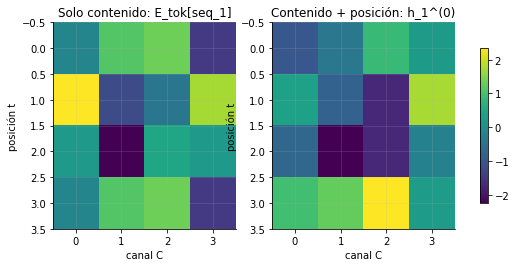

In [2]:
resultado_posicion = posicion.preparar_experimento_posicion_orden(
    seed=7,
    dimension=4,
    seq_1_tokens=("a", "b", "c", "a"),
    seq_2_tokens=("c", "a", "a", "b"),
)

block_size = resultado_posicion.block_size
C = resultado_posicion.dimension
vocab = resultado_posicion.vocab
id_a_token = resultado_posicion.id_a_token

mostrar_tablas_en_columnas([
    ("Formas principales", resultado_posicion.formas),
    ("Permutación por posición", resultado_posicion.comparacion),
    ("Token repetido en otra posición", resultado_posicion.repeticion),
], min_width="320px")

display(resultado_posicion.figura)
plt.close(resultado_posicion.figura)


La tabla separa contenido, ubicación y representación inicial. En la comparación por posición, las dos secuencias usan los mismos tokens, pero ningún token queda en la misma columna temporal. Esto obliga a distinguir entre identidad de token y lugar dentro de la ventana.

La fila “token repetido en otra posición” resume el caso clave: el mismo token consulta la misma fila de `E_tok`, pero al aparecer en otra posición recibe otra fila de `E_pos`. Por eso $h_t^{(0)}$ no dice solo qué token aparece; dice qué token aparece en una posición concreta.


## Explorador interactivo de contenido y posición

El siguiente explorador permite cambiar la secuencia, la dimensión $C$ y la posición $t$. Observe dos casos: tokens repetidos, donde se conserva la fila de contenido pero cambia la fila posicional; y tokens permutados, donde cambia qué contenido aparece en una misma posición.


In [3]:
import fundamentos_transformers.componentes_interactivos as componentes_interactivos

componentes_interactivos = importlib.reload(componentes_interactivos)

explorador_posicion = componentes_interactivos.crear_explorador_posicion_orden(
    dimension_inicial=4,
)
display(explorador_posicion)

## Límite de una tabla posicional aprendida

Una tabla posicional aprendida tiene un número finito de filas. Si `block_size = 4`, existen filas para $t=0,1,2,3$. Consultar $t=4$ no es extrapolación automática: es pedir una fila que no existe.

In [4]:
resultado_limite = posicion.preparar_limite_tabla_posicional(block_size)

mostrar_tablas_en_columnas([
    ("Filas disponibles", resultado_limite.limites),
    ("Consulta fuera de rango", resultado_limite.consulta),
], min_width="360px")


## Interpretación

La señal posicional convierte una representación de contenido en una representación de contenido ubicado. Sumar posición no destruye el contenido: agrega una segunda fuente de información en la misma dimensión $C$.

Antes de sumar posición, el modelo solo dispone de vectores de contenido. El token `a` consulta la misma fila de `E_tok` cada vez que aparece. Después de sumar posición, dos apariciones del mismo token pueden producir representaciones iniciales distintas porque se combinan con filas diferentes de `E_pos`.

El explorador ayuda a separar token, posición e instancia. Una misma fila de contenido puede participar en varias posiciones, y una misma posición puede recibir contenidos distintos cuando cambia el orden de la secuencia. La representación $h_t^{(0)}$ une ambas fuentes para que la atención compare posiciones ya identificables.

`block_size` condiciona la tabla posicional absoluta aprendida: define cuántas posiciones pueden consultarse directamente. Por eso la longitud de contexto es una decisión de datos y también de arquitectura.

Esta señal todavía no resuelve dependencias largas. Solo prepara la entrada para que las capas posteriores puedan aprender comparaciones entre posiciones.


## Verificación de aprendizaje

Use el explorador interactivo y cambie una sola variable: secuencia, posición $t$ o dimensión $C$. Luego reporte evidencia concreta:

1. qué token aparece en la posición seleccionada;
2. qué fila de `E_tok` consulta ese token;
3. qué fila de `E_pos` consulta la posición;
4. por qué ambas filas deben tener dimensión $C$;
5. un caso donde el mismo token aparezca en otra posición y explique qué se conserva antes de sumar posición y qué cambia después;
6. un caso donde cambie el token en la misma posición y explique qué cambia en $h_t^{(0)}$;
7. qué ocurre si se consulta una posición mayor o igual que `block_size` en una tabla absoluta aprendida.


## Análisis crítico

La señal posicional permite distinguir orden, pero no resuelve por sí sola el modelado de dependencias. Solo prepara la representación inicial para que las capas de atención puedan comparar posiciones con información de contenido y ubicación.

Tampoco hay una única forma correcta de representar posición. La tabla absoluta aprendida es simple y útil para este curso; otros esquemas buscan mejorar extrapolación, relaciones relativas o eficiencia en contextos largos.

## Síntesis

$$
(x_t,t) \rightarrow E_{\text{tok}}[x_t] + E_{\text{pos}}[t] \rightarrow h_t^{(0)}
$$

Esta cadena se lee así: la representación inicial de una posición combina la identidad del token y su ubicación en la ventana.

<div style="border-left: 4px solid #1f2a44; padding: 10px 14px; background: #f6f8fa; margin: 14px 0;">
La idea central es que el Transformer no puede tratar una secuencia solo como una bolsa de tokens. Necesita una señal explícita de orden para que la atención opere sobre posiciones distinguibles.
</div>

## Preguntas de discusión

1. ¿Qué errores cometería un modelo sin información posicional?
2. ¿Por qué la suma exige que token y posición tengan la misma dimensión $C$?
3. ¿Qué relación hay entre `block_size` y una tabla posicional absoluta aprendida?
4. ¿Qué ventaja podría tener un esquema relativo o rotatorio frente a una tabla absoluta?
5. ¿Por qué esta señal todavía no equivale a comprender dependencias largas?

## Continuidad

El siguiente notebook se concentra en manipular de forma segura las dimensiones tensoriales. Esa alfabetización será necesaria para entender atención, cabezas múltiples y proyecciones lineales.